<a href="https://colab.research.google.com/github/aronnaiqbal/220153_SMV/blob/main/220153_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [28]:
url = "https://raw.githubusercontent.com/aronnaiqbal/220153_SMV/refs/heads/main/dataset/Titanic-Dataset.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
d

In [30]:
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']

df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

print(df.head())

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


In [31]:
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

df[['Age']] = num_imputer.fit_transform(df[['Age']])
df[['Embarked']] = cat_imputer.fit_transform(df[['Embarked']])

In [32]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [33]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [35]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

In [36]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)

SVC(probability=True)

In [37]:
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01],
    'degree': [2, 3]
}

grid = GridSearchCV(
    SVC(probability=True),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}


In [38]:
best_model = grid.best_estimator_

In [39]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [40]:
acc = accuracy_score(y_test,y_pred)
pre = precision_score(y_test,y_pred)
rec = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
auc = roc_auc_score(y_test,y_prob)

print("Accuracy:",acc)
print("Precision:",pre)
print("Recall:",rec)
print("F1 Score:",f1)
print("AUC:",auc)

Accuracy: 0.7985074626865671
Precision: 0.75
Recall: 0.6382978723404256
F1 Score: 0.6896551724137931
AUC: 0.8160919540229885


In [41]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85        87
           1       0.75      0.64      0.69        47

    accuracy                           0.80       134
   macro avg       0.78      0.76      0.77       134
weighted avg       0.79      0.80      0.79       134



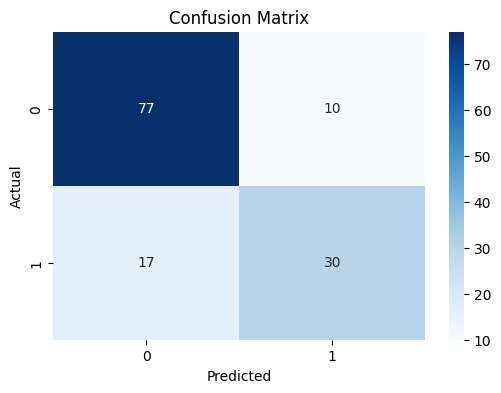

In [42]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

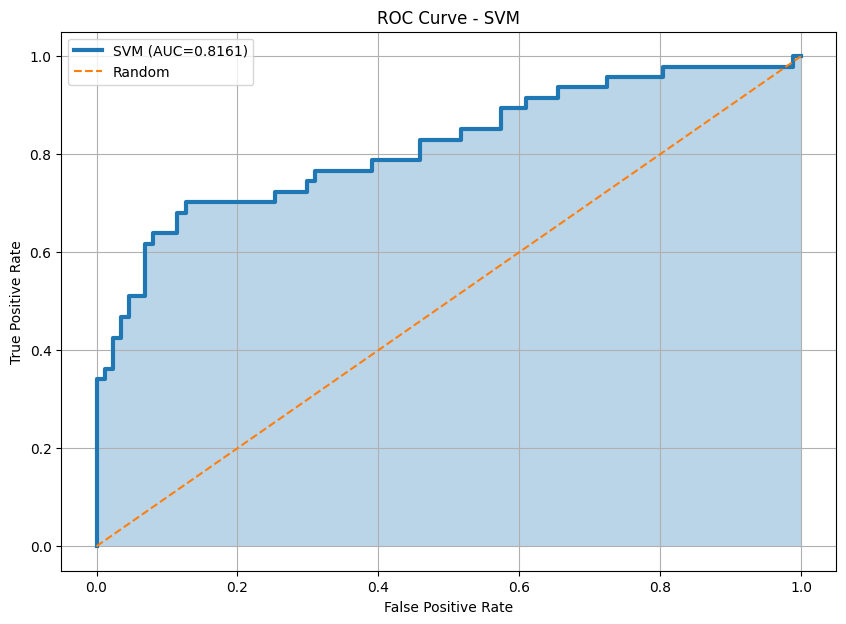

In [43]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(10,7))
plt.plot(fpr,tpr,linewidth=3,label=f'SVM (AUC={auc_score:.4f})')
plt.fill_between(fpr,tpr,alpha=0.3)
plt.plot([0,1],[0,1],'--',label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.grid()
plt.show()

In [44]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability': y_prob
})

print(results.head(10))

   Actual  Predicted  Probability
0       0          0     0.146712
1       0          0     0.149920
2       1          0     0.391449
3       0          0     0.141998
4       0          0     0.136707
5       0          1     0.813276
6       0          0     0.146247
7       0          0     0.145506
8       0          0     0.148525
9       0          0     0.145519


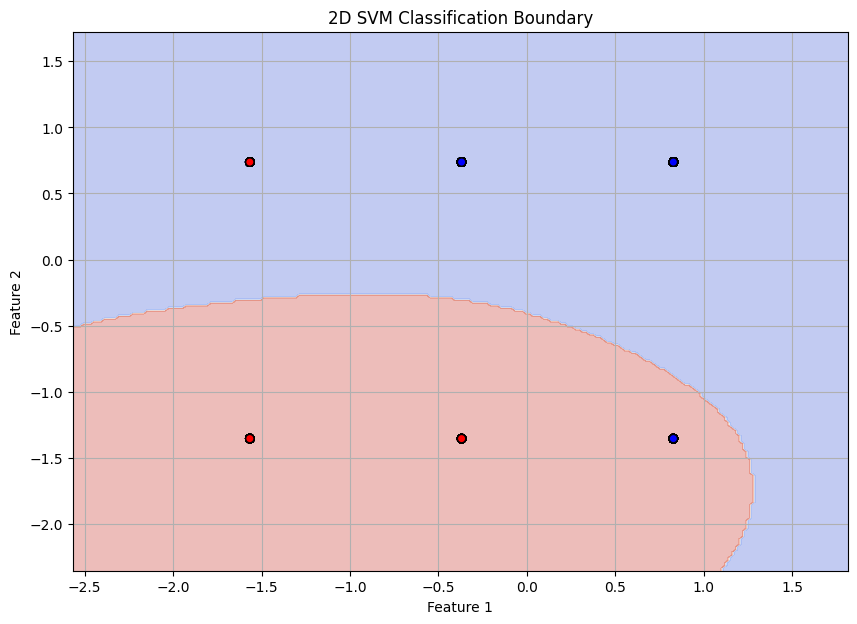

In [45]:
X_plot = X_scaled[:, :2]

model_2d = SVC(kernel='rbf')
model_2d.fit(X_plot, y)

x_min, x_max = X_plot[:,0].min()-1, X_plot[:,0].max()+1
y_min, y_max = X_plot[:,1].min()-1, X_plot[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min,x_max,0.02),
    np.arange(y_min,y_max,0.02)
)

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,7))
plt.contourf(xx,yy,Z,alpha=0.35,cmap='coolwarm')
plt.scatter(
    X_plot[:,0],
    X_plot[:,1],
    c=y,
    cmap='bwr',
    edgecolors='black'
)
plt.title("2D SVM Classification Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid()
plt.show()

In [46]:
print("First 5 rows:")
df.head()

First 5 rows:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [47]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(891, 8)


In [48]:
print("Columns:")
print(df.columns)

Columns:
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')


In [49]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


In [50]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.647587,29.699118,0.523008,0.381594,32.204208,1.536476
std,0.486592,0.836071,0.477990,13.002015,1.102743,0.806057,49.693429,0.791503
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400,1.000000
50%,0.000000,3.000000,1.000000,29.699118,0.000000,0.000000,14.454200,2.000000
75%,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000,2.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,2.000000


In [51]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


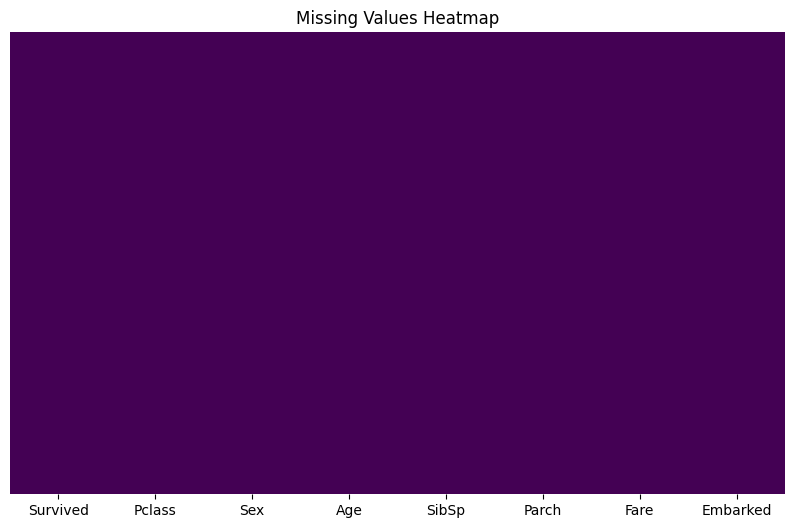

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=False,
            cmap='viridis')

plt.title("Missing Values Heatmap")
plt.show()

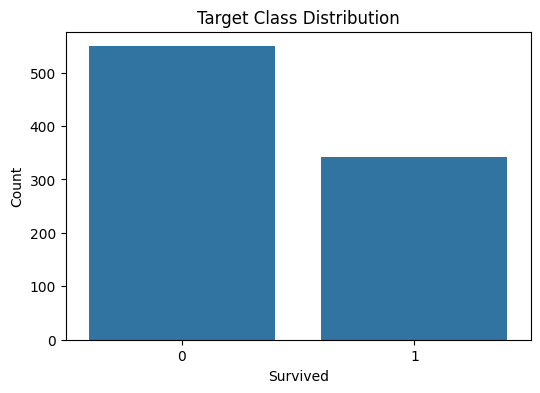

In [53]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)

plt.title("Target Class Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

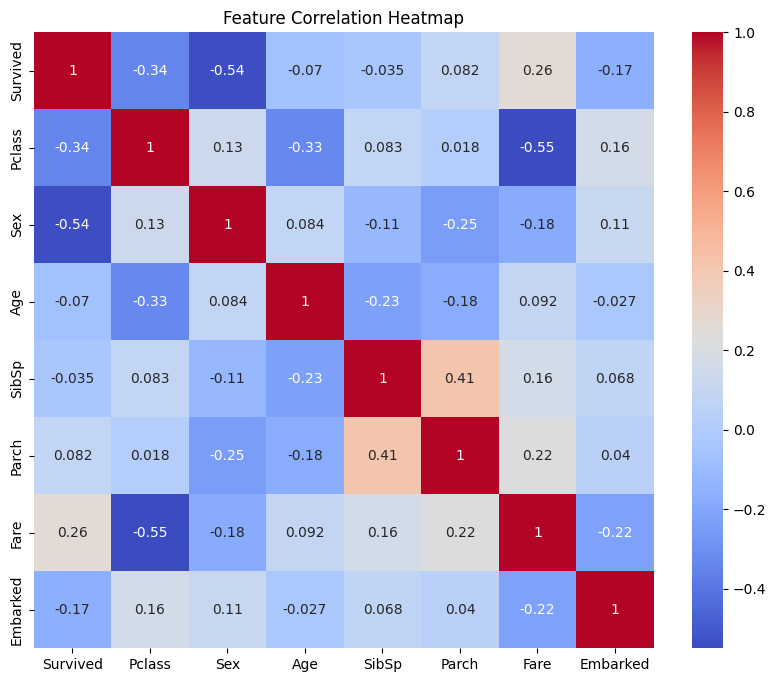

In [54]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

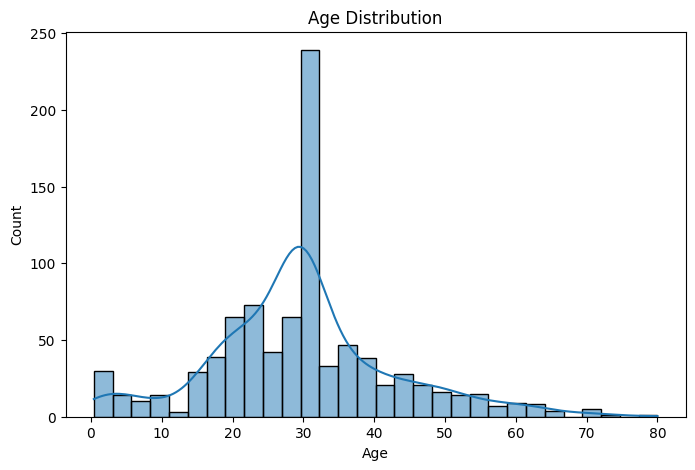

In [55]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

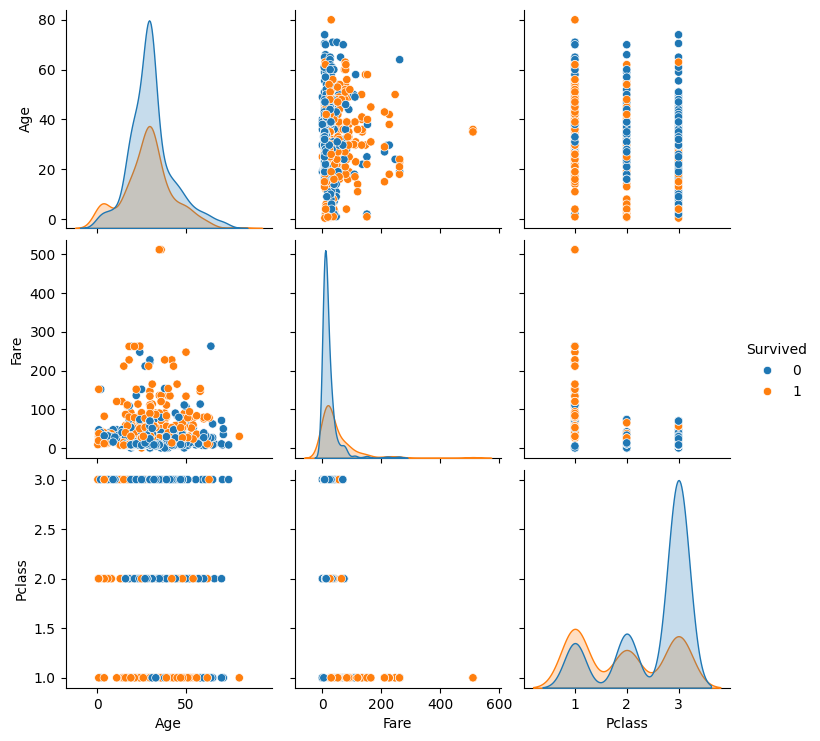

In [56]:
sns.pairplot(df[['Age','Fare','Pclass','Survived']],
             hue='Survived')
plt.show()